# Section 1 — Dataset Loading and Initial Audit

This section loads the PIMA Indians Diabetes dataset and performs an initial medically informed audit of data quality, missingness, and feature validity.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Load PIMA Indians Diabetes Dataset

The PIMA Indians Diabetes dataset is a widely used benchmark dataset for binary diabetes prediction. It contains clinical measurements collected from female patients of Pima Indian heritage aged 21 years or older.

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome",
]

df = pd.read_csv(url, names=columns)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [5]:
invalid_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in invalid_cols:

    invalid_count = (df[col] == 0).sum()
    invalid_percent = (invalid_count / len(df)) * 100

    print(f"{col}")
    print(f"Invalid zeros: {invalid_count}")
    print(f"Percentage: {invalid_percent:.2f}%")
    print("-" * 40)

Glucose
Invalid zeros: 5
Percentage: 0.65%
----------------------------------------
BloodPressure
Invalid zeros: 35
Percentage: 4.56%
----------------------------------------
SkinThickness
Invalid zeros: 227
Percentage: 29.56%
----------------------------------------
Insulin
Invalid zeros: 374
Percentage: 48.70%
----------------------------------------
BMI
Invalid zeros: 11
Percentage: 1.43%
----------------------------------------


In [6]:
df[invalid_cols] = df[invalid_cols].replace(0, np.nan)

In [7]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

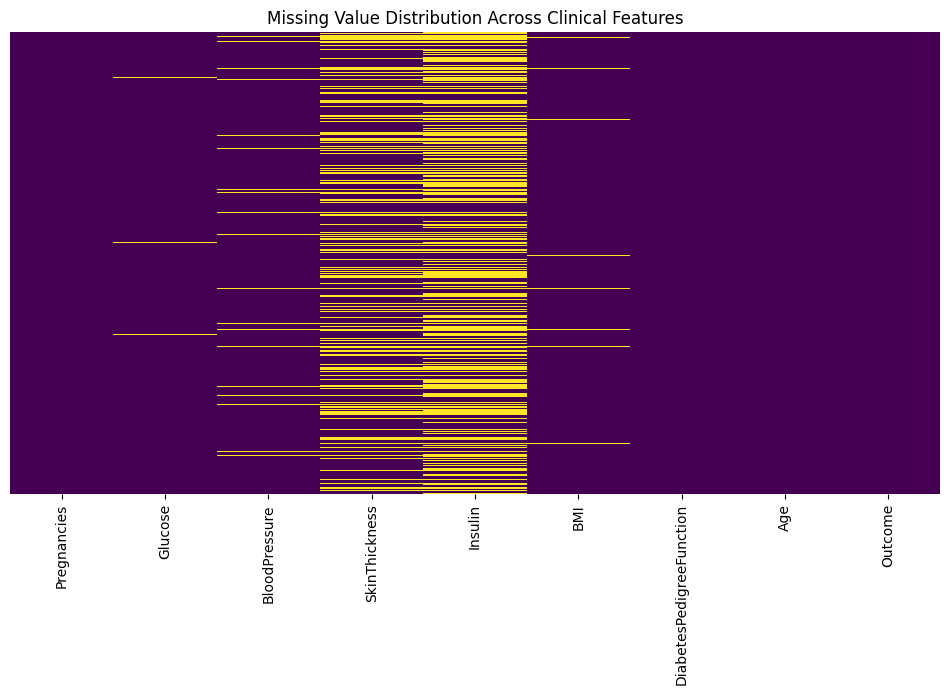

In [8]:
plt.figure(figsize=(12, 6))

sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")

plt.title("Missing Value Distribution Across Clinical Features")

plt.show()

In [9]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

df[invalid_cols] = imputer.fit_transform(df[invalid_cols])

In [10]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

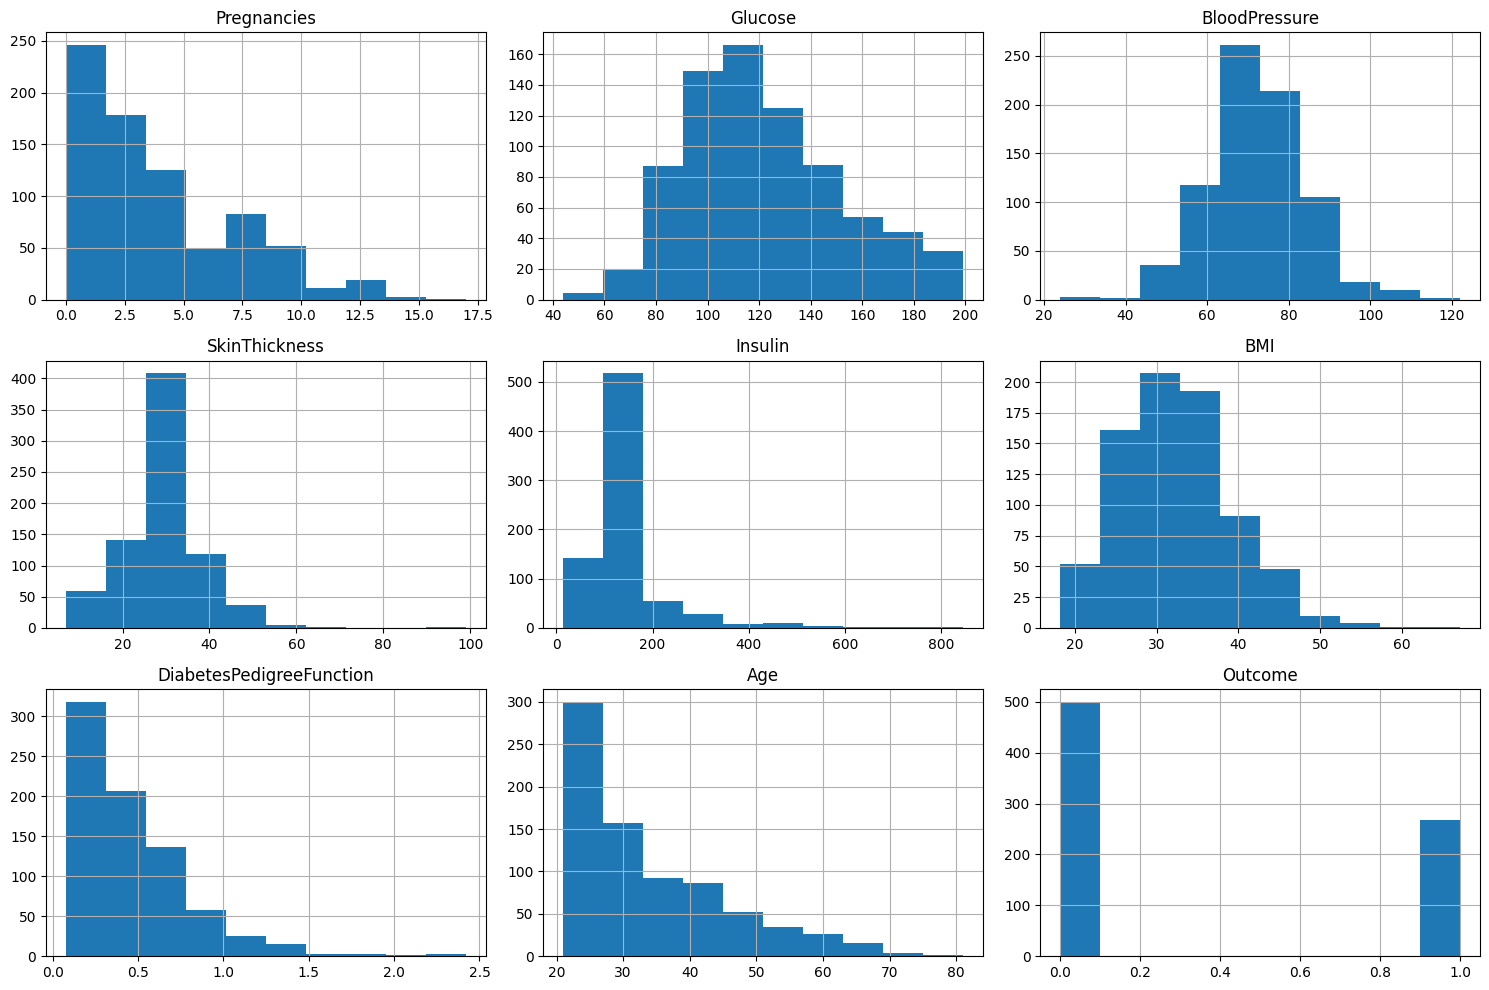

In [11]:
df.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

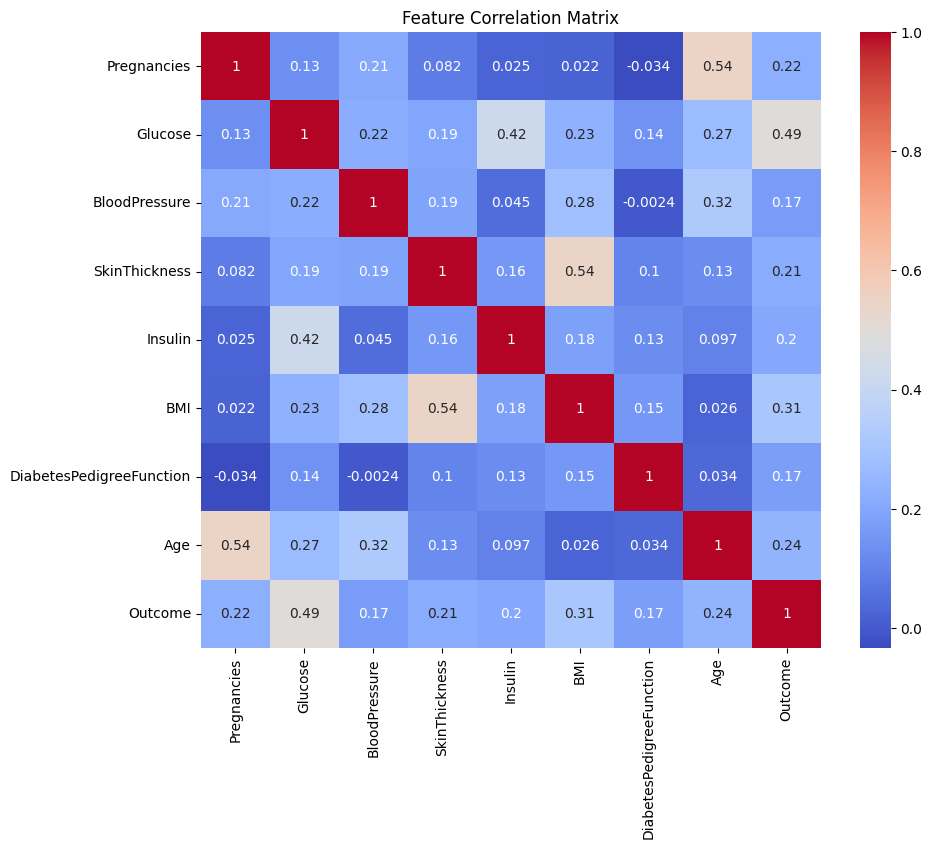

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

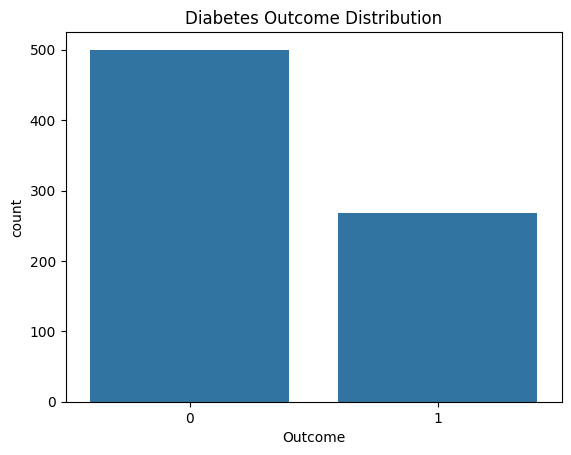

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


In [13]:
sns.countplot(x=df["Outcome"])
plt.title("Diabetes Outcome Distribution")
plt.show()
print(df["Outcome"].value_counts(normalize=True))

In [14]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
print(X.shape)
print(y.shape)

(768, 8)
(768,)


In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
from sklearn.model_selection import RepeatedStratifiedKFold
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=42)

### Preliminary Scaling Experiment

Initial standardization was performed globally for exploratory analysis. However, to avoid data leakage during cross-validation, all subsequent experiments use a fold-aware sklearn Pipeline where scaling occurs independently within each training fold.

In [18]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [19]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
}

In [20]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

In [21]:
from sklearn.model_selection import cross_validate

results = []

for name, model in models.items():

    pipeline = Pipeline([("scaler", StandardScaler()), ("model", model)])

    scores = cross_validate(
        pipeline, X, y, cv=cv, scoring=scoring, return_train_score=False
    )

    results.append(
        {
            "Model": name,
            "Accuracy Mean": scores["test_accuracy"].mean(),
            "Accuracy Std": scores["test_accuracy"].std(),
            "F1 Mean": scores["test_f1"].mean(),
            "F1 Std": scores["test_f1"].std(),
            "ROC_AUC Mean": scores["test_roc_auc"].mean(),
            "ROC_AUC Std": scores["test_roc_auc"].std(),
        }
    )

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy Mean,Accuracy Std,F1 Mean,F1 Std,ROC_AUC Mean,ROC_AUC Std
0,Logistic Regression,0.765129,0.041572,0.616666,0.080459,0.836673,0.047678
1,Random Forest,0.765169,0.044958,0.641670,0.072034,0.830263,0.049619
2,XGBoost,0.745580,0.053831,0.630438,0.080605,0.802145,0.054099
3,CatBoost,0.762526,0.046295,0.640204,0.080874,0.839075,0.047898


# Section 3 — Hyperparameter Optimization

Baseline experiments revealed performance variability across models, with CatBoost achieving the highest mean ROC-AUC. To obtain a statistically robust predictive model for downstream explainability and counterfactual analysis, Bayesian hyperparameter optimization is performed using Optuna.

In [22]:
import optuna

## Optuna Objective Function

Bayesian optimization is performed over CatBoost hyperparameters using repeated stratified cross-validation. The optimization objective maximizes mean ROC-AUC across folds while preserving evaluation robustness under class imbalance.

In [23]:
from sklearn.model_selection import cross_val_score


def objective(trial):

    params = {
        "iterations": trial.suggest_int("iterations", 100, 500),
        "depth": trial.suggest_int("depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "random_strength": trial.suggest_float("random_strength", 1e-9, 10, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1),
        "verbose": 0,
        "random_state": 42,
    }

    model = CatBoostClassifier(**params)

    pipeline = Pipeline([("scaler", StandardScaler()), ("model", model)])

    scores = cross_val_score(pipeline, X, y, cv=cv, scoring="roc_auc")

    return scores.mean()

## Bayesian Hyperparameter Search

An Optuna study is initialized to maximize cross-validated ROC-AUC. Bayesian optimization enables efficient exploration of the hyperparameter space compared to exhaustive grid search.

In [24]:
study = optuna.create_study(direction="maximize")

[I 2026-05-07 14:21:37,953] A new study created in memory with name: no-name-26ef88e7-4936-4cd0-b9b0-d9c0e02bff40


In [25]:
study.optimize(objective, n_trials=30)

[I 2026-05-07 14:22:53,584] Trial 0 finished with value: 0.8131234567901234 and parameters: {'iterations': 344, 'depth': 6, 'learning_rate': 0.2793978697106758, 'l2_leaf_reg': 9.099280315662778, 'border_count': 83, 'random_strength': 0.06440879995075052, 'bagging_temperature': 0.5325894928667511}. Best is trial 0 with value: 0.8131234567901234.
[I 2026-05-07 14:23:52,043] Trial 1 finished with value: 0.8257530864197531 and parameters: {'iterations': 165, 'depth': 10, 'learning_rate': 0.12298334447982284, 'l2_leaf_reg': 6.26612275902106, 'border_count': 95, 'random_strength': 0.0031956086706386505, 'bagging_temperature': 0.5979839196327748}. Best is trial 1 with value: 0.8257530864197531.
[I 2026-05-07 14:24:21,482] Trial 2 finished with value: 0.8330227920227921 and parameters: {'iterations': 350, 'depth': 4, 'learning_rate': 0.03687762124787806, 'l2_leaf_reg': 9.264273654737265, 'border_count': 141, 'random_strength': 6.577966732354316e-06, 'bagging_temperature': 0.5579714574327789}. 

In [26]:
print("Best ROC-AUC:", study.best_value)
print("\nBest Parameters:\n")
study.best_params

Best ROC-AUC: 0.8475593542260207

Best Parameters:



{'iterations': 468,
 'depth': 4,
 'learning_rate': 0.013492561527386536,
 'l2_leaf_reg': 4.002428271522091,
 'border_count': 176,
 'random_strength': 9.565907582261651,
 'bagging_temperature': 0.9968917611925809}

# Section 4 — Optimized Model Evaluation

The optimized CatBoost model is evaluated under repeated stratified cross-validation to assess predictive robustness, variance stability, and discrimination capability following Bayesian hyperparameter optimization.

In [27]:
best_model = CatBoostClassifier(**study.best_params, verbose=0, random_state=42)

In [28]:
optimized_pipeline = Pipeline([("scaler", StandardScaler()), ("model", best_model)])

optimized_scores = cross_validate(
    optimized_pipeline, X, y, cv=cv, scoring=scoring, return_train_score=False
)

In [29]:
optimized_results = {
    "Accuracy Mean": optimized_scores["test_accuracy"].mean(),
    "Accuracy Std": optimized_scores["test_accuracy"].std(),
    "F1 Mean": optimized_scores["test_f1"].mean(),
    "F1 Std": optimized_scores["test_f1"].std(),
    "ROC_AUC Mean": optimized_scores["test_roc_auc"].mean(),
    "ROC_AUC Std": optimized_scores["test_roc_auc"].std(),
}

pd.DataFrame([optimized_results])

,Accuracy Mean,Accuracy Std,F1 Mean,F1 Std,ROC_AUC Mean,ROC_AUC Std
0,0.764719,0.040625,0.624847,0.072685,0.847559,0.044788


# Section 5 — Model Calibration

In healthcare prediction systems, probabilistic reliability is critical for trustworthy decision support. A classifier with high discrimination performance may still produce poorly calibrated probabilities, leading to overconfident or underconfident risk estimates.

To assess probabilistic trustworthiness, calibration analysis is performed using reliability curves and Brier score evaluation.

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [31]:
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay

In [32]:
base_model = CatBoostClassifier(**study.best_params, verbose=0, random_state=42)

pipeline = Pipeline([("scaler", StandardScaler()), ("model", base_model)])

calibrated_model = CalibratedClassifierCV(pipeline, method="isotonic", cv=5)

In [33]:
calibrated_model.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step... verbose=0))])
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit 

In [34]:
y_prob = calibrated_model.predict_proba(X_test)[:, 1]

y_pred = calibrated_model.predict(X_test)

In [35]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_test, y_prob)

print("Brier Score:", round(brier, 4))

Brier Score: 0.169


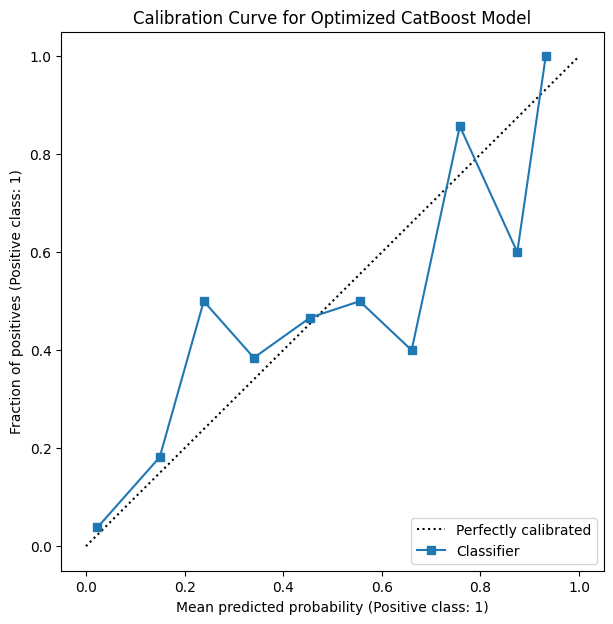

In [36]:
fig, ax = plt.subplots(figsize=(7, 7))

CalibrationDisplay.from_predictions(y_test, y_prob, n_bins=10, ax=ax)

plt.title("Calibration Curve for Optimized CatBoost Model")

plt.show()

In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.81      0.80       100
           1       0.63      0.59      0.61        54

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



# Section 6 — SHAP-Based Explainability Analysis

To improve interpretability and transparency of diabetes risk prediction, SHAP (SHapley Additive exPlanations) analysis is performed on the optimized CatBoost model.

SHAP provides both global and local explanations by quantifying feature contributions to individual predictions using cooperative game theory principles.

In [38]:
final_model = CatBoostClassifier(**study.best_params, verbose=0, random_state=42)

final_pipeline = Pipeline([("scaler", StandardScaler()), ("model", final_model)])

final_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [39]:
trained_model = final_pipeline.named_steps["model"]

In [40]:
scaler = final_pipeline.named_steps["scaler"]

X_train_scaled = scaler.transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [42]:
import shap
explainer = shap.TreeExplainer(trained_model)

In [43]:
shap_values = explainer.shap_values(X_test_scaled)

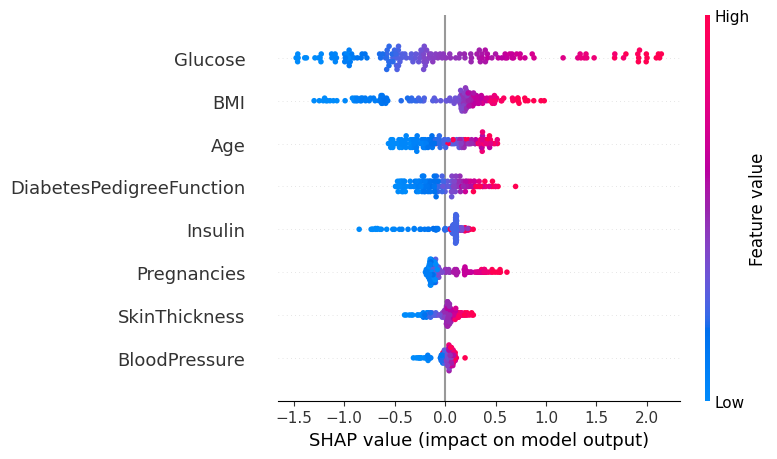

In [44]:
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)

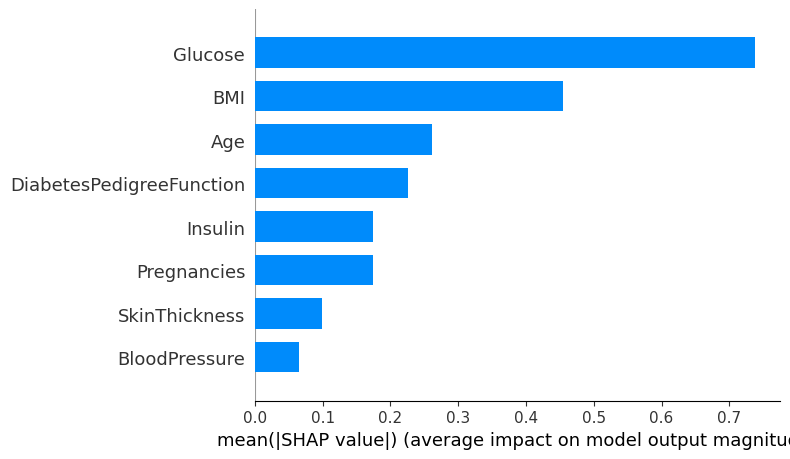

In [45]:
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns, plot_type="bar")

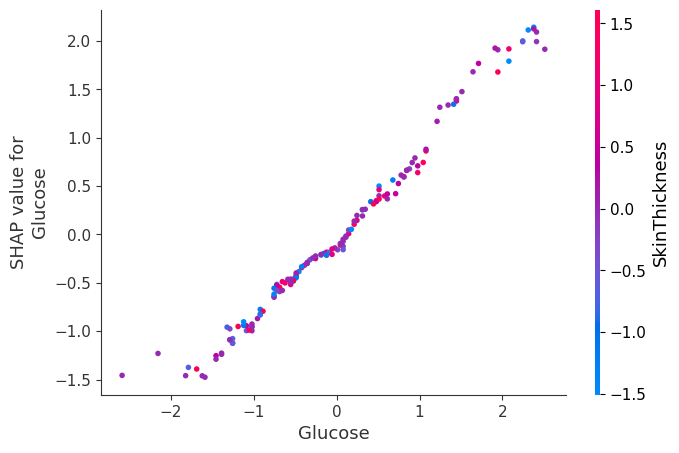

In [46]:
shap.dependence_plot("Glucose", shap_values, X_test_scaled, feature_names=X.columns)

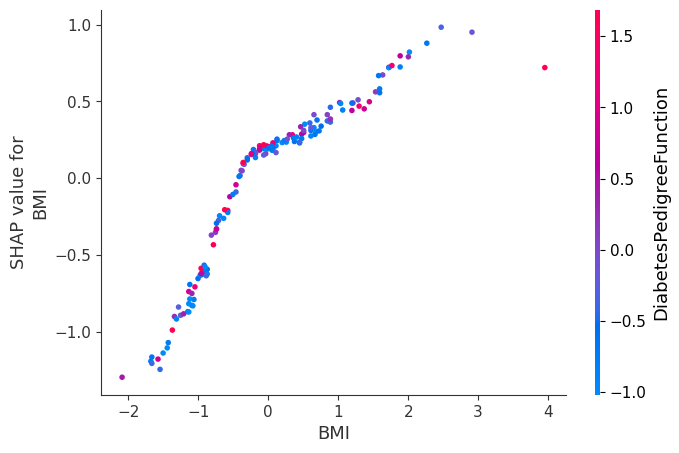

In [47]:
shap.dependence_plot("BMI", shap_values, X_test_scaled, feature_names=X.columns)

In [48]:
patient_index = 0

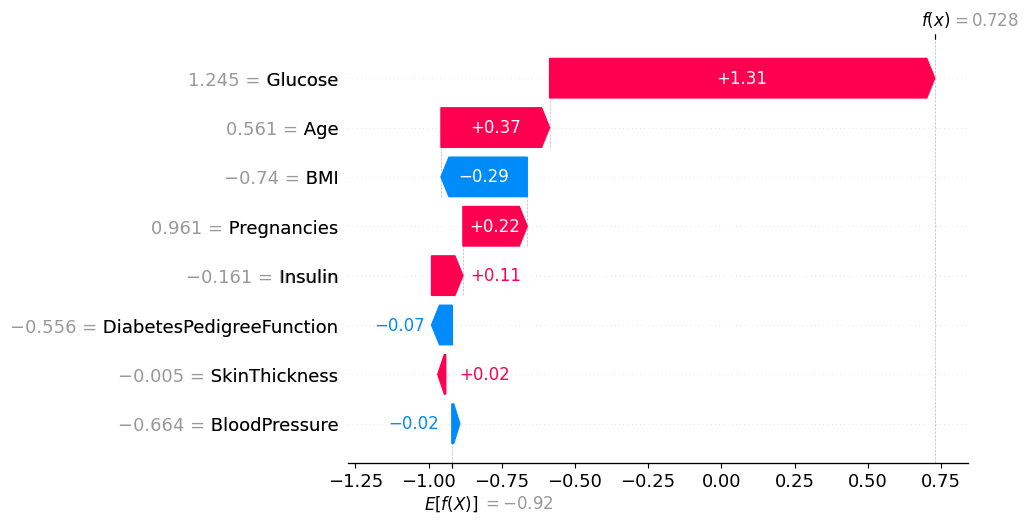

In [49]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[patient_index],
        base_values=explainer.expected_value,
        data=X_test_scaled[patient_index],
        feature_names=X.columns.tolist(),
    )
)

In [50]:
X_test.iloc[patient_index]

Pregnancies                   7.000
Glucose                     159.000
BloodPressure                64.000
SkinThickness                29.000
Insulin                     125.000
BMI                          27.400
DiabetesPedigreeFunction      0.294
Age                          40.000
Name: 44, dtype: float64

# Section 7 — Medically Constrained Counterfactual Framework

To improve the realism and trustworthiness of generated counterfactual explanations, medically informed feasibility constraints are introduced during recourse generation. Features are categorized according to mutability and physiological plausibility to discourage unrealistic interventions.

In [51]:
feature_constraints = {
    "Pregnancies": {"mutable": False},
    "Glucose": {"mutable": True, "min_change": -30, "max_change": 30},
    "BloodPressure": {"mutable": True, "min_change": -20, "max_change": 20},
    "SkinThickness": {"mutable": True, "min_change": -15, "max_change": 15},
    "Insulin": {"mutable": True, "min_change": -50, "max_change": 50},
    "BMI": {"mutable": True, "min_change": -5, "max_change": 5},
    "DiabetesPedigreeFunction": {"mutable": False},
    "Age": {"mutable": False},
}

In [52]:
import dice_ml

In [53]:
dice_data = dice_ml.Data(
    dataframe=df,
    continuous_features=[
        "Pregnancies",
        "Glucose",
        "BloodPressure",
        "SkinThickness",
        "Insulin",
        "BMI",
        "DiabetesPedigreeFunction",
        "Age",
    ],
    outcome_name="Outcome",
)

In [54]:
dice_model = dice_ml.Model(model=trained_model, backend="sklearn")

In [59]:
explainer_cf = dice_ml.Dice(dice_data, dice_model, method="genetic")

In [60]:
query_instance = X_test.iloc[[patient_index]]

In [61]:
calibrated_model.predict_proba(query_instance)

array([[0.3159045, 0.6840955]])

In [ ]:
counterfactuals = explainer_cf.generate_counterfactuals(
    query_instance,
    total_CFs=5,
    desired_class="opposite",
    features_to_vary=["Glucose", "BMI"],
    maxiterations=500,
)

  0%|          | 0/1 [12:27<?, ?it/s]


KeyboardInterrupt: 

2. MEDICAL DATA AUDIT

3. MISSING DATA

4. EDA

5. PREPROCESSING PIPELINE

6. BASELINE MODELS

7. EVALUATION